# PyTorch Convolutional Neural Network Exercise: MNIST

In this notebook, you will build a convolutional neural network that recognizes handwritten digits from the MNIST dataset.

Unlike a fully connected network, a convolutional network preserves the spatial structure of an image. Its filters scan small local regions, detect useful patterns, and combine those patterns into increasingly abstract representations.

## Learning objectives

By the end of the exercise, you should be able to:

- explain why image tensors include channel, height, and width dimensions
- describe what convolution and pooling layers do
- calculate how image dimensions change through a CNN
- build a convolutional classifier with `nn.Conv2d`
- train the network with mini-batches
- evaluate validation and test performance
- inspect correct and incorrect predictions
- interpret a confusion matrix
- visualize learned convolutional filters and feature maps

## Exercise style

Most missing expressions use the format `variable = ...`. Replace the ellipsis with the complete right-hand-side expression.

The training and evaluation loops are different: they contain staged `TODO` comments so that you can organize the loop body yourself.

## 1. Import the libraries and select a device

PyTorch performs tensor calculations on a CPU or GPU. Google Colab can provide a GPU when the runtime is configured for hardware acceleration, but the notebook also works on a CPU.

The device-selection code is provided. Every model and batch must be placed on the same device before calculations are performed.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(7)
np.random.seed(7)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


## 2. Load MNIST

MNIST contains grayscale images of handwritten digits from `0` to `9`. Each image is 28 pixels high and 28 pixels wide.

`transforms.ToTensor()` performs two useful conversions:

- it changes the image from a PIL image into a PyTorch tensor
- it scales pixel values from integers in the range 0–255 to floating-point values in the range 0–1

The dataset-loading code is provided because the focus of this exercise is the convolutional network.

### Hint

**Core APIs:** `datasets.MNIST(...)` and `transforms.ToTensor()`

In [4]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Full training samples:", len(full_train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.80MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]

Full training samples: 60000
Test samples: 10000


## 3. Inspect one image

A single MNIST item contains an image tensor and an integer label.

PyTorch image tensors use the shape:

```text
channels × height × width
```

MNIST is grayscale, so it has one channel. A single image should therefore have shape `(1, 28, 28)`.

The inspection code is provided. Run it and verify the tensor shape, label, and pixel-value range.

In [5]:
image, label = full_train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Image shape: torch.Size([1, 28, 28])
Label: 5
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 4. Visualize sample images

Display several images before building the model. This confirms that the labels match the handwritten digits and helps you understand the variation the network must learn to handle.

The visualization code is provided because plotting is not the main learning objective in this section.

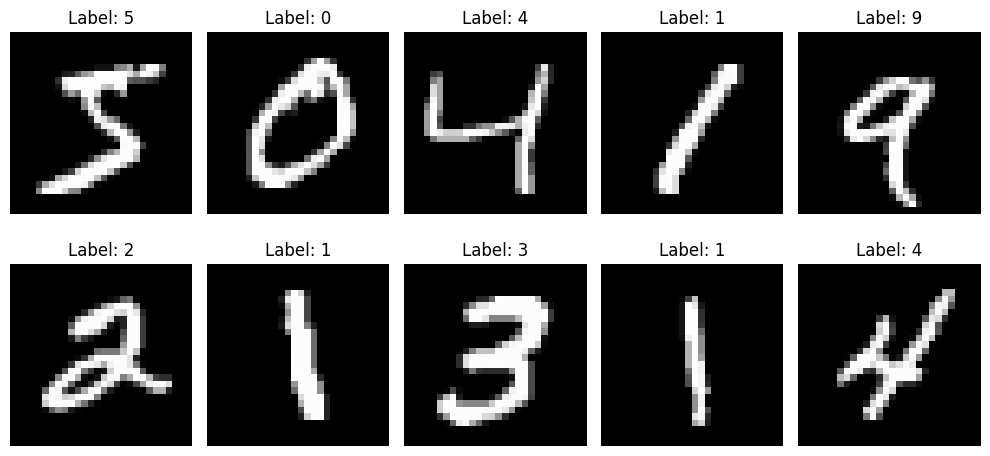

In [6]:
figure, axes = plt.subplots(2, 5, figsize=(10, 5))

for index, axis in enumerate(axes.flat):

    sample_image, sample_label = full_train_dataset[index]

    axis.imshow(
        sample_image.squeeze(),
        cmap="gray"
    )

    axis.set_title(f"Label: {sample_label}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## 5. Create training, validation, and test loaders

The original MNIST training set contains 60,000 images. This notebook uses:

- 54,000 images for parameter updates
- 6,000 images for validation
- 10,000 separate images for final testing

A `DataLoader` groups observations into mini-batches. Mini-batch training updates the model after each batch rather than after the entire dataset.

**Exercise:** Complete the code below to split the training set and initialize the loaders.

### Requirements
1. Split `full_train_dataset` into 54,000 training and 6,000 validation samples using a manual seed of `7` for reproducibility.
2. Create a `train_loader` that shuffles the data.
3. Create `validation_loader` and `test_loader` (these should not be shuffled).
4. Use a `batch_size` of 64.

### Hint
**Core APIs:** `random_split(...)` and `DataLoader(...)`

In [7]:
import torch
from torch.utils.data import DataLoader, random_split

# TODO 1: Split full_train_dataset into train_dataset (54,000) and validation_dataset (6,000).
# Use torch.Generator().manual_seed(7) inside random_split for reproducibility.
gen = torch.Generator().manual_seed(7)
train_dataset, validation_dataset = random_split(full_train_dataset, [54000, 6000], generator=gen)

batch_size = 64

# TODO 2: Create a DataLoader for the training set.
# Ensure it uses the defined batch_size and has shuffle=True.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# TODO 3: Create a DataLoader for the validation set.
# Ensure it uses the defined batch_size and has shuffle=False.
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# TODO 4: Create a DataLoader for the test set.
# Ensure it uses the defined batch_size and has shuffle=False.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verify the loader lengths
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 844
Validation batches: 94
Test batches: 157


## 6. Inspect one mini-batch

A batch of MNIST images has four dimensions:

```text
batch size × channels × height × width
```

With a batch size of 64, the image tensor should have shape `(64, 1, 28, 28)`. The label tensor should contain one class index for each image.

The code is provided. Run it before defining the network so that the input dimensions are clear.

In [8]:
batch_images, batch_labels = next(iter(train_loader))

print("Image batch shape:", batch_images.shape)
print("Label batch shape:", batch_labels.shape)
print("First ten labels:", batch_labels[:10])

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
First ten labels: tensor([0, 2, 1, 0, 5, 2, 7, 2, 7, 8])


## 7. Understand the CNN architecture

The network will use two convolutional blocks followed by a fully connected classifier.

```text
Input: 1 × 28 × 28

Conv2d: 1 channel → 16 channels, 3 × 3 kernel, padding 1
ReLU
MaxPool2d: 2 × 2
Output: 16 × 14 × 14

Conv2d: 16 channels → 32 channels, 3 × 3 kernel, padding 1
ReLU
MaxPool2d: 2 × 2
Output: 32 × 7 × 7

Flatten
Linear: 32 × 7 × 7 → 128
ReLU
Linear: 128 → 10
```

Padding keeps the height and width unchanged during each convolution. Each 2 × 2 pooling layer halves the height and width.

The final layer has 10 outputs because MNIST contains 10 classes. These outputs are logits, so the network should not include a final softmax layer.

## 8. Build the convolutional neural network

Separate the model into two components:

- `self.features` extracts spatial features with convolution and pooling
- `self.classifier` converts the extracted features into class logits

Complete the expressions assigned to `self.features`, `self.classifier`, `features`, and `logits`.

### Hint

**Core classes:** `nn.Sequential`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, `nn.Flatten`, and `nn.Linear`

**Example Commands:**
- `nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)`: Creates a convolutional layer.
- `nn.MaxPool2d(kernel_size=2)`: Creates a pooling layer that halves height and width.
- `nn.Linear(in_features=32 * 7 * 7, out_features=128)`: Creates a fully connected layer.
- `nn.Flatten()`: Reshapes the 4D feature tensor into a 2D tensor for the linear layers.

The first linear layer receives `32 % 7 % 7` input values because the second block outputs 32 channels of size 7x7.

In [9]:
class MNISTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32 * 7 * 7, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):

        features = self.features(x)

        logits = self.classifier(features)

        return logits


model = MNISTCNN().to(device)

print(model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 9. Count the parameters

Trainable parameters are the weights and biases changed by the optimizer.

A convolutional network often uses fewer parameters than a fully connected network that connects every image pixel directly to a large hidden layer. Convolution reuses the same filter weights at many image locations.

Complete the expression assigned to `parameter_count`.

### Hint

Each trainable tensor is available through `model.parameters()`. Count the elements only when `requires_grad` is true.

In [10]:
parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {parameter_count:,}")

Trainable parameters: 206,922


## 10. Inspect one forward pass

Pass one batch through the untrained model.

For a batch containing 64 images, the output should have shape `(64, 10)`. Each row represents one image. Each column represents the score for one digit class.

Complete the expression assigned to `sample_logits`.

### Hint

Move the image batch to the same device as the model before calling the model.

In [11]:
sample_images = batch_images.to(device)

sample_logits = model(sample_images)

print("Logit shape:", sample_logits.shape)
print("First logit vector:")
print(sample_logits[0])

Logit shape: torch.Size([64, 10])
First logit vector:
tensor([ 0.0876,  0.0662,  0.0124, -0.0181, -0.0327, -0.0395, -0.0372,  0.0538,
        -0.0480, -0.0118], grad_fn=<SelectBackward0>)


## 11. Define the loss function and optimizer

Cross-entropy loss compares the model's ten logits with the correct class index.

Adam updates the model parameters using the gradients calculated during backpropagation. A learning rate of `0.001` is a common starting point for this model.

Complete the expressions assigned to `criterion` and `optimizer`.

### Hint

**Core APIs:** `nn.CrossEntropyLoss()` and `torch.optim.Adam(...)`

The optimizer must receive the model's trainable parameters.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 12. Implement one training epoch

A training epoch processes every mini-batch once.

For each batch, the function must:

1. move images and labels to the selected device
2. clear gradients from the previous batch
3. perform a forward pass
4. calculate the batch loss
5. backpropagate the loss
6. update the model parameters
7. accumulate loss and correct predictions

The function's outer structure and metric calculations are provided. Write the training stages under the `TODO` comments. You may choose your own intermediate variable names, but the function must return average loss and accuracy.

### Hint

The batch loss should be multiplied by the batch size before it is added to `running_loss`. This converts the mean batch loss back into a total that can be averaged correctly across the entire dataset.

In [13]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        # TODO 1: Move the image and label batch to the device.
        images = images.to(device)
        labels = labels.to(device)

        # TODO 2: Clear gradients from the previous batch.
        optimizer.zero_grad()

        # TODO 3: Perform the forward pass.
        logits = model(images)

        # TODO 4: Calculate the batch loss.
        loss = criterion(logits, labels)

        # TODO 5: Backpropagate the loss.
        loss.backward()

        # TODO 6: Update the model parameters.
        optimizer.step()

        # TODO 7: Add this batch's contribution to running_loss.
        running_loss += loss.item() * images.size(0)

        # TODO 8: Convert the logits into predicted classes.
        _, predicted = torch.max(logits.data, 1)

        # TODO 9: Update correct and total.
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

## 13. Implement the evaluation loop

Validation and testing use a similar loop, but no parameter updates occur.

The evaluation function must:

1. switch the model to evaluation mode
2. disable gradient tracking
3. move each batch to the device
4. calculate logits and loss
5. accumulate loss and correct predictions
6. return average loss and accuracy

Write the missing stages under the `TODO` comments.

### Hint

Do not call `optimizer.zero_grad()`, `loss.backward()`, or `optimizer.step()` during evaluation.

In [14]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            # TODO 1: Move the image and label batch to the device.
            images = images.to(device)
            labels = labels.to(device)

            # TODO 2: Perform the forward pass.
            logits = model(images)

            # TODO 3: Calculate the loss.
            loss = criterion(logits, labels)

            # TODO 4: Add this batch's contribution to running_loss.
            running_loss += loss.item() * images.size(0)

            # TODO 5: Convert the logits into predicted classes.
            _, predicted = torch.max(logits.data, 1)

            # TODO 6: Update correct and total.
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

## 14. Train for several epochs

The driver code calls the two functions you implemented.

After each epoch, it records:

- training loss
- validation loss
- training accuracy
- validation accuracy

Validation performance helps reveal whether the model is improving on unseen data. If training accuracy continues to rise while validation accuracy falls, the model may be overfitting.

Three epochs are enough for this exercise to demonstrate the complete workflow while keeping Colab runtime reasonable.

In [15]:
num_epochs = 3

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    train_accuracies.append(train_accuracy)
    validation_accuracies.append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.3f} | "
        f"Validation accuracy: {validation_accuracy:.3f}"
    )

Epoch 1/3 | Train loss: 0.2510 | Validation loss: 0.0708 | Train accuracy: 0.925 | Validation accuracy: 0.979
Epoch 2/3 | Train loss: 0.0644 | Validation loss: 0.0497 | Train accuracy: 0.981 | Validation accuracy: 0.985
Epoch 3/3 | Train loss: 0.0455 | Validation loss: 0.0433 | Train accuracy: 0.986 | Validation accuracy: 0.987


## 15. Plot training and validation loss

Loss curves show how confidently the model fits the data.

A healthy pattern usually includes decreasing training and validation loss. A widening gap between them can indicate overfitting.

Complete the expression assigned to `loss_lines`.

### Hint

Call `plt.plot(...)` once for the training history and once for the validation history. Store both returned line lists together.

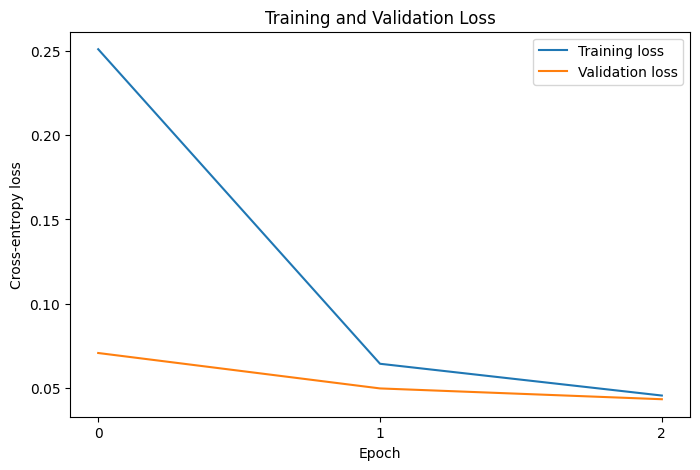

In [16]:
plt.figure(figsize=(8, 5))

loss_lines = plt.plot(train_losses, label="Training loss"), \
             plt.plot(validation_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and Validation Loss")
plt.xticks(range(num_epochs))
plt.legend()
plt.show()

## 16. Plot training and validation accuracy

Accuracy curves show the proportion of images classified correctly.

Validation accuracy is generally more informative than training accuracy because validation images are not used for parameter updates.

Complete the expression assigned to `accuracy_lines`.

### Hint

Plot `train_accuracies` and `validation_accuracies` on the same axes and assign a label to each curve.

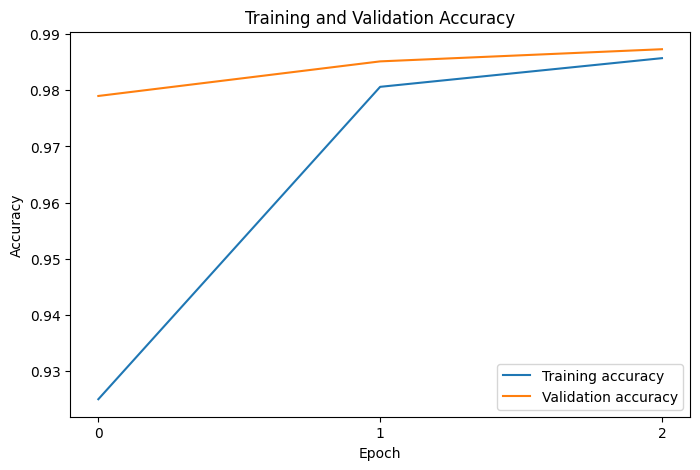

In [17]:
plt.figure(figsize=(8, 5))

accuracy_lines = plt.plot(train_accuracies, label="Training accuracy"), \
                 plt.plot(validation_accuracies, label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.xticks(range(num_epochs))
plt.legend()
plt.show()

## 17. Evaluate the final model on the test set

The test set should be used only after the model design and training process are complete.

This final accuracy estimates how well the model generalizes to new MNIST images. Complete the expression assigned to `test_loss` and `test_accuracy`.

### Hint

Use the evaluation function that you already implemented.

In [19]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.3f}")

Test loss: 0.0402
Test accuracy: 0.986


## 18. Collect all test predictions

The helper function below runs the model across the test loader and returns the predicted and actual labels in dataset order.

This code is provided because it repeats the evaluation pattern you have already implemented. The resulting tensors will be used for visual examples and the confusion matrix.

In [20]:
def collect_predictions(
    model,
    loader,
    device
):

    model.eval()

    prediction_batches = []
    label_batches = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            logits = model(images)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            prediction_batches.append(
                predictions.cpu()
            )

            label_batches.append(labels)

    all_predictions = torch.cat(
        prediction_batches
    )

    all_labels = torch.cat(
        label_batches
    )

    return all_predictions, all_labels


all_predictions, all_labels = collect_predictions(
    model,
    test_loader,
    device
)

print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)

Predictions: torch.Size([10000])
Labels: torch.Size([10000])


## 19. Visualize test predictions

The code below displays the first twelve test images together with the predicted and actual labels.

Correct predictions have matching values. Differences between the two labels identify mistakes.

The visualization code is provided so that you can focus on interpreting the model's behavior.

In [ ]:
figure, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

for index, axis in enumerate(axes.flat):

    image, actual_label = test_dataset[index]

    predicted_label = all_predictions[index].item()

    axis.imshow(
        image.squeeze(),
        cmap="gray"
    )

    axis.set_title(
        f"Predicted: {predicted_label}\n"
        f"Actual: {actual_label}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

## 20. Inspect incorrect predictions

Incorrect examples reveal which writing styles or digit pairs are difficult for the network.

First find every index where the predicted label differs from the actual label. Then the provided plotting code will display the first twelve mistakes.

Complete the expression assigned to `incorrect_indexes`.

### Hint

Compare `all_predictions` with `all_labels`, then use `torch.where(...)`.

Incorrect predictions: 137


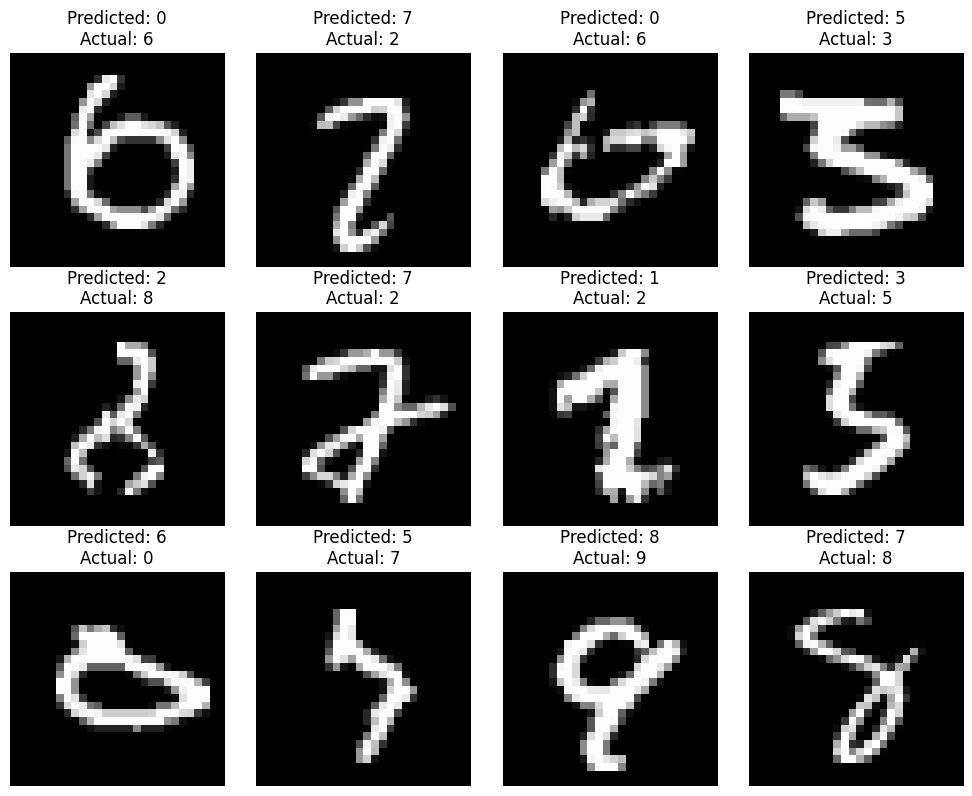

In [21]:
incorrect_indexes = torch.where(all_predictions != all_labels)[0]

print(
    "Incorrect predictions:",
    len(incorrect_indexes)
)

figure, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

for plot_index, axis in enumerate(axes.flat):

    dataset_index = incorrect_indexes[plot_index].item()

    image, actual_label = test_dataset[dataset_index]

    predicted_label = all_predictions[
        dataset_index
    ].item()

    axis.imshow(
        image.squeeze(),
        cmap="gray"
    )

    axis.set_title(
        f"Predicted: {predicted_label}\n"
        f"Actual: {actual_label}"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

## 21. Create a confusion matrix

A confusion matrix counts how often each actual digit is predicted as each possible digit.

Rows represent actual classes. Columns represent predicted classes. Large values outside the main diagonal reveal common confusions, such as one handwritten digit resembling another.

Complete the expressions assigned to `confusion` and `display`.

### Hint

**Core APIs:** `confusion_matrix(...)` and `ConfusionMatrixDisplay(...)`

Convert the tensors to NumPy arrays before passing them to scikit-learn.

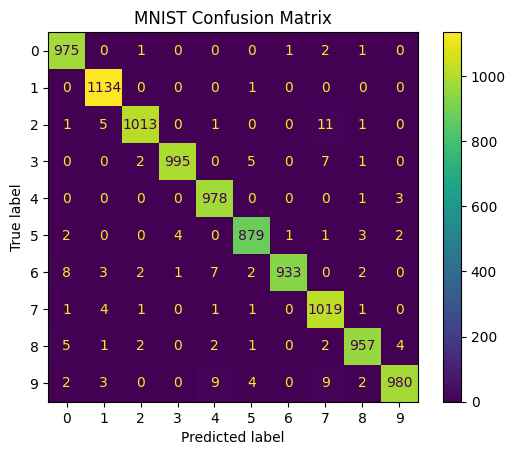

In [22]:
confusion = confusion_matrix(
    all_labels.numpy(),
    all_predictions.numpy()
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=list(range(10))
)

display.plot()
plt.title("MNIST Confusion Matrix")
plt.show()

## 22. Visualize the first-layer filters

The first convolutional layer learns 16 small filters. Each filter contains a 3 × 3 pattern that is applied across the image.

Early filters often respond to simple structures such as edges, strokes, or intensity transitions. The values may not look like recognizable digits because they represent low-level detectors rather than complete objects.

Complete the expression assigned to `first_layer_filters`.

### Hint

The first convolution is `model.features[0]`. Access its weights, detach them from gradient tracking, and move them to the CPU.

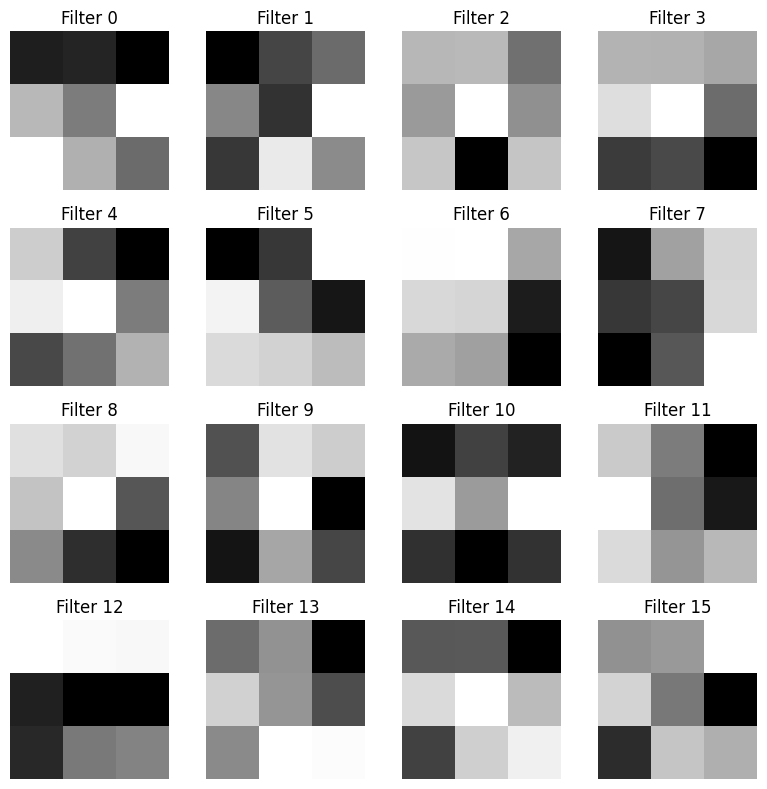

In [23]:
first_layer_filters = model.features[0].weight.data.detach().cpu()

figure, axes = plt.subplots(
    4,
    4,
    figsize=(8, 8)
)

for index, axis in enumerate(axes.flat):

    axis.imshow(
        first_layer_filters[index, 0],
        cmap="gray"
    )

    axis.set_title(f"Filter {index}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## 23. Visualize first-layer feature maps

A filter becomes useful when it is applied to an image. The resulting activation is called a feature map.

Different feature maps emphasize different parts of the same digit. Some may respond strongly to vertical strokes, curved regions, or edges.

Complete the expression assigned to `feature_maps`.

### Hint

Pass a one-image batch through the first convolutional layer, apply ReLU, then move the result to the CPU for plotting.

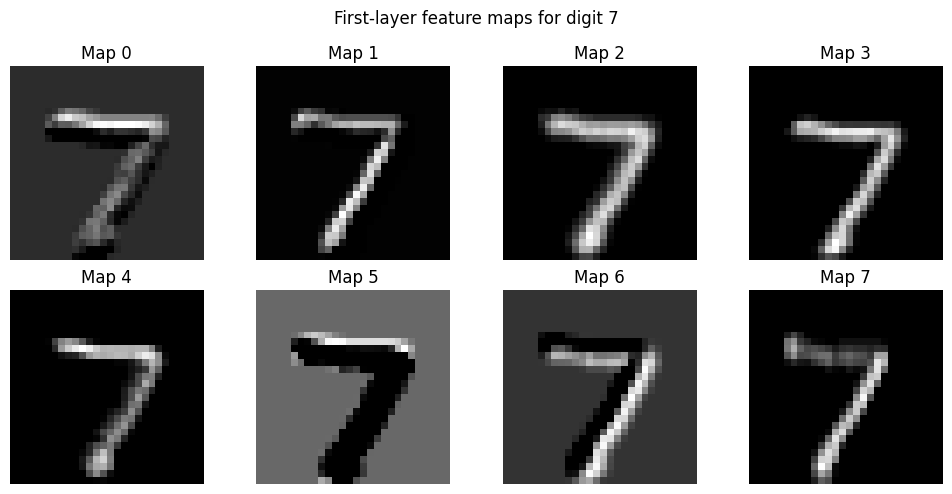

In [24]:
sample_image, sample_label = test_dataset[0]

sample_batch = (
    sample_image
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():

    feature_maps = model.features[1](model.features[0](sample_batch))

feature_maps = feature_maps.cpu()

figure, axes = plt.subplots(
    2,
    4,
    figsize=(10, 5)
)

for index, axis in enumerate(axes.flat):

    axis.imshow(
        feature_maps[0, index],
        cmap="gray"
    )

    axis.set_title(f"Map {index}")
    axis.axis("off")

plt.suptitle(
    f"First-layer feature maps for digit {sample_label}"
)
plt.tight_layout()
plt.show()

## 24. Architecture extension

Build a wider CNN to reinforce how channel counts affect later dimensions.

Use this architecture:

```text
Conv2d: 1 → 32
MaxPool2d
Conv2d: 32 → 64
MaxPool2d
Flatten
Linear: 64 × 7 × 7 → 128
Linear: 128 → 10
```

You do not need to train the wider model in this notebook. Build it, run one batch through it, and compare its parameter count with the original model.

Complete `self.features`, `self.classifier`, `features`, and `logits`.

### Hint

The spatial dimensions still become 7 × 7 after two pooling operations, but the final feature tensor now contains 64 channels.

In [25]:
class WiderMNISTCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 7 * 7, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):

        features = self.features(x)

        logits = self.classifier(features)

        return logits


wider_model = WiderMNISTCNN().to(device)

wider_logits = wider_model(
    batch_images.to(device)
)

wider_parameter_count = sum(
    parameter.numel()
    for parameter in wider_model.parameters()
    if parameter.requires_grad
)

print("Wider output shape:", wider_logits.shape)
print(
    f"Original parameters: {parameter_count:,}"
)
print(
    f"Wider parameters: {wider_parameter_count:,}"
)

Wider output shape: torch.Size([64, 10])
Original parameters: 206,922
Wider parameters: 421,642


## 25. Short-answer questions

Answer each question in one or two sentences.

1. Why does the first convolutional layer use `in_channels=1`?
2. What does `out_channels=16` mean?
3. Why does padding of 1 preserve the 28 × 28 spatial dimensions for a 3 × 3 kernel?
4. What does max pooling do to the height and width?
5. Why does the first linear layer receive `32 × 7 × 7` values?
6. Why should the final layer contain 10 outputs?
7. Why is softmax omitted from the model?
8. What is the difference between training mode and evaluation mode?
9. Why should test data not be used to choose the architecture?
10. What information does a confusion matrix provide that accuracy does not?

### Answers

1.  Because the input MNIST images are grayscale, meaning they have only one color channel.
2.  The convolutional layer will learn 16 different filters and make 16 feature maps as its output.
3.  Adds a 1-pixel border around the input, which increases its dimensions so that after convolution, the output dimensions match the input dimensions.
4.  Halves the height and width of the input feature map.
5.  So the spatial dimensions of each feature map become 7x7. Since there are 32 such feature maps, flattening them creates `32 * 7 * 7` values.
6.  The MNIST dataset has 10 distinct digit classes (0 through 9) that the model needs to classify.
7. `nn.CrossEntropyLoss` internally applies a softmax operation to the model's raw logits, so it doesn't have to be a separate layer.
8.  In training mode, the model enables gradient calculations, dropout, and batch normalization updates; in evaluation mode, these are disabled to ensure consistent and deterministic predictions.
9.  It would cause overfitting in the test set and unreliable estimate of the model's real-world performance.
10. How many predictions were correct or incorrect but also which classes were confused with each other.